# Chapter 10: Other Neural Structures

### Setting up our M5 dataset

1.  Configuring our dataset: First, the related imports and configurations. We place the dataset
inside a folder called data alongside the script/notebook where our code runs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from Utilities.PathUtilities import get_current_working_directory
custom_palette = [
 "#000000", "#0072B2", "#D55E00",
 "#009E73","#CC79A7", "#56B4E9","#E69F00"
]

class CFG:
    data_folder = get_current_working_directory().parent / "data"
    img_dim1 = 12
    img_dim2 = 6
    fontsize = 14

plt.rcParams.update({'figure.figsize': (CFG.img_dim1,CFG.img_dim2)})

2. Loading and preprocessing the data: To explore the dataset, we need to load it and convert it
into a pandas dataframe. We build a function to achieve this.

In [2]:
from pathlib import Path

def load_m5_subset(data_folder: Path) -> pd.DataFrame:
    # Construct filepath
    filepath = data_folder / 'M5_t20_ABC.csv'

    # Verify file exists
    if not filepath.exists():
        raise FileNotFoundError(f"Data file not found at {filepath}")

    # Read data
    df = pd.read_csv(filepath, index_col=0)

    # Convert date to datetime
    df['date'] = pd.to_datetime(df['date'])

    # Remove last 28 days of each series
    df_sorted = df.sort_values(['item_id', 'date'])

    def remove_tail_values(group):
        return group.iloc[:-28]

    df = df_sorted.groupby('item_id', group_keys=False).apply(remove_tail_values).reset_index(drop=True)

    # Add time-based features
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['dayofweek'] = df['date'].dt.dayofweek
    df['quarter'] = df['date'].dt.quarter
    df['week_of_year'] = df['date'].dt.isocalendar().week
    return df

3. Summarizing the dataset: We also need to get some basic statistics of the dataset. We use the
following function to compute the summary statistics of the M5 competition dataset.

In [3]:
def analyze_dataset(df: pd.DataFrame) -> dict:
    # Get ABC distribution by unique products
    abc_dist = df.groupby('item_id')['ABC_class'].first().value_counts().to_dict()
    analysis = {
    'n_series': df['item_id'].nunique(),
    'n_stores': df['state_id'].nunique(),
    'date_range': (df['date'].min(), df['date'].max()),
    'total_sales': df['sold'].sum(),
    'mean_price': df['sell_price'].mean(),
    'abc_distribution': abc_dist,
    'sales_by_class': df.groupby(
    'ABC_class')['sold'].sum().to_dict(),
    'avg_price_by_class': df.groupby(
    'ABC_class')['sell_price'].mean().to_dict()
    }
    return analysis

4. Visualizing patterns: And finally, we need to build a function to plot out some examples of
the sales data:

In [4]:
def plot_sales_analysis(series: pd.DataFrame, figsize=(15, 10)):
    fig, axes = plt.subplots(2, 1, figsize=figsize)
    # Sales over time
    axes[0].plot(
    series['date'], series['sold'],
    color = custom_palette[1], alpha=0.7)
    axes[0].set_title(
        f"Sales Over Time for {series['item_id'].iloc[0]}")
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Units Sold')

    # Sales by day of week
    sns.boxplot(
    data=series, x='dayofweek', y='sold',
    ax=axes[1], color = custom_palette[2]
    )
    axes[1].set_title('Sales Distribution by Day of Week')
    axes[1].set_xlabel('Day of Week')
    axes[1].set_ylabel('Units Sold')
    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\nSummary Statistics: " f"{series['sold'].describe()}")

5. Modeling a subset of the data: To be able to investigate multiple models quickly, we create
a small subset of time series taken from the M5 competition, from locn_id (location) CA.
Let’s quickly load this data:

In [5]:
from pandas import Timestamp

df = load_m5_subset(CFG.data_folder)
# Analyze dataset
analysis = analyze_dataset(df)
analysis
{'n_series': 60,
'n_stores': 1,
'date_range': (Timestamp('2011-01-29 00:00:00'),
 Timestamp('2016-05-22 00:00:00')),
'total_sales': 1815356,
'mean_price': 2.719599776747381,
'abc_distribution': {'C': 20, 'B': 20, 'A': 20},
'sales_by_class': {'A': 1456556, 'B': 271653, 'C': 87147},
'avg_price_by_class': {'A': 1.7382524471921692,
 'B': 2.8056069036579085,
 'C': 3.614939979392066}}

C:\Users\brend\AppData\Local\Temp\ipykernel_151308\1171140153.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df_sorted.groupby('item_id', group_keys=False).apply(remove_tail_values).reset_index(drop=True)


{'n_series': 60,
 'n_stores': 1,
 'date_range': (Timestamp('2011-01-29 00:00:00'),
  Timestamp('2016-05-22 00:00:00')),
 'total_sales': 1815356,
 'mean_price': 2.719599776747381,
 'abc_distribution': {'C': 20, 'B': 20, 'A': 20},
 'sales_by_class': {'A': 1456556, 'B': 271653, 'C': 87147},
 'avg_price_by_class': {'A': 1.7382524471921692,
  'B': 2.8056069036579085,
  'C': 3.614939979392066}}

A quick analysis of our data shows we have 60 unique items, tracked over 5.5 years (January
2011 until June 2016). The items are evenly split across the ABC classification, with 20 products
in each group. 'A' items are high-volume products that make up about 80% of total sales (1.46
million out of 1.82 million units). 'B' items are medium-volume and account for around 15% (272,000 units), while 'C' items are low-volume and make up the remaining 5% (87,000
units). This kind of difference in sales volume is normal, but in this case, we created the distribution on purpose. In the original data, you’d see something like: A = 15%, B = 25%, and C =
60% of items. We can also see a clear trend between sales volume and pricing — high-volume
'A' items tend to be cheaper (averaging $1.74), while low-volume 'C' items are more expensive
(averaging $3.62).

6. Exploring variation in different time series: Let’s plot out some series to investigate some of the patterns in our dataset:

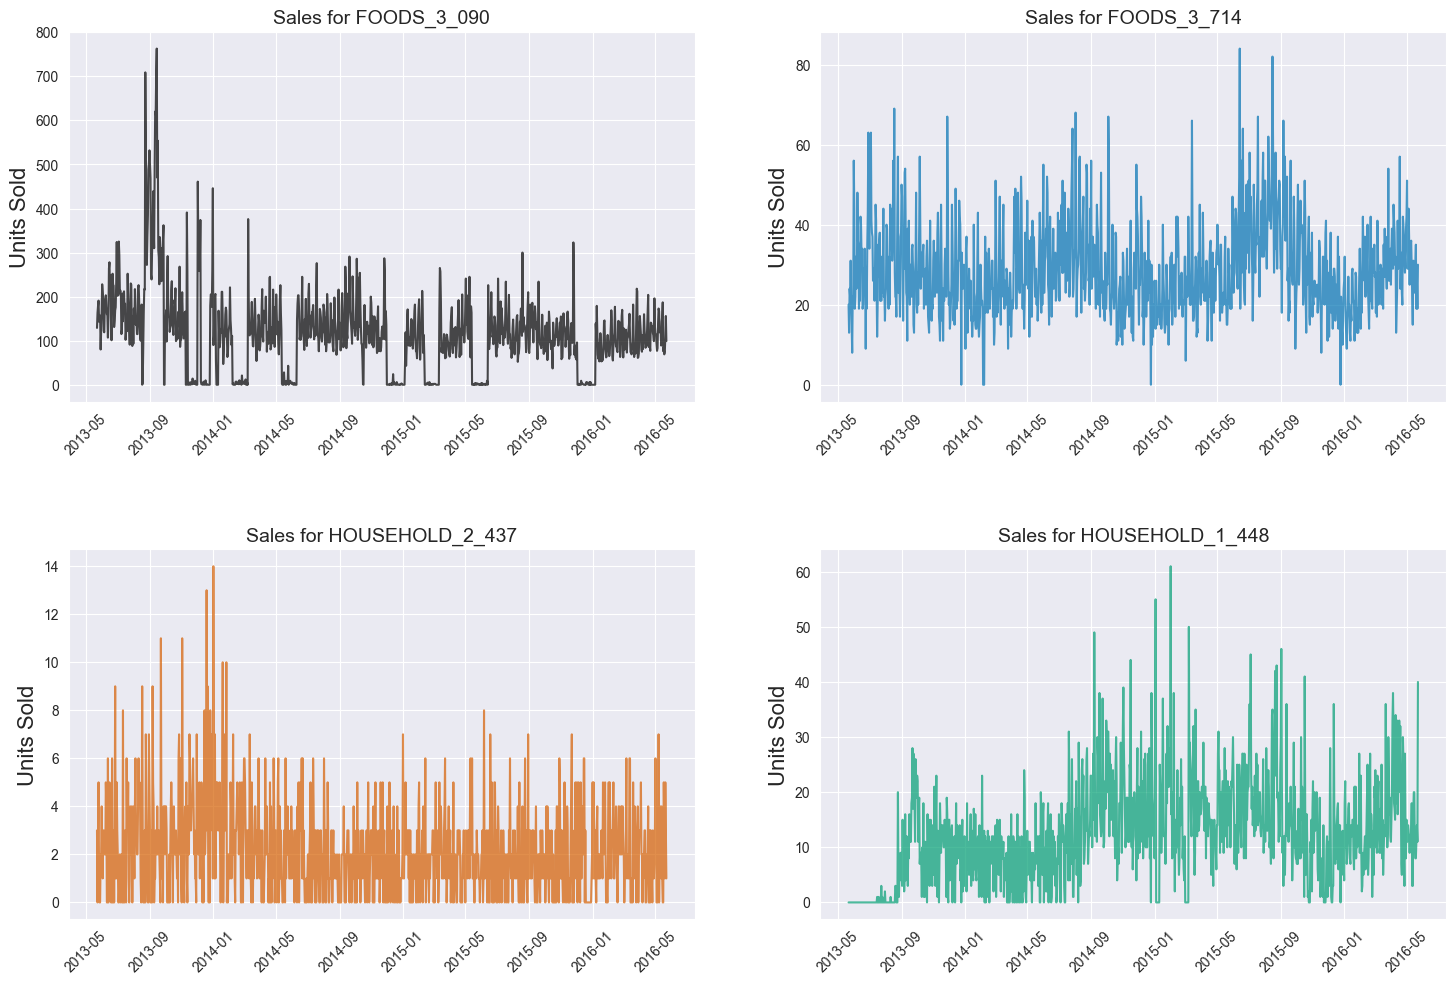

In [7]:
# Select series to plot
series_to_plot = [
 'FOODS_3_090', 'FOODS_3_714',
 'HOUSEHOLD_2_437', 'HOUSEHOLD_1_448'
]
# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.tight_layout(pad=3.0)
# Flatten axes for easier iteration
axes = axes.flatten()
for idx, (series_id, ax) in enumerate(zip(series_to_plot, axes)):
    # Get single series
    series = df[df['item_id'] == series_id].copy()
    series = series.sort_values('date')

    # Get last 36 months
    last_date = series['date'].max()
    start_date = last_date - pd.DateOffset(months=36)
    series = series[series['date'] >= start_date]

    # Plot
    ax.plot(series['date'], series['sold'],color=custom_palette[idx],alpha=0.7)
    ax.set_title(f"Sales for {series_id}", fontsize=14)
    ax.set_ylabel('Units Sold', fontsize=16)
    ax.tick_params(axis='x', rotation=45)
plt.subplots_adjust(hspace=0.4, wspace=0.2)
plt.show()

Looking at a few individual time series, we can see some variation. The first item (FOOD_3_090), which we have seen earlier, has a high magnitude of sales but has several data drop offs. There are several such instances in the dataset, and it is unlikely that we can model these sets perfectly without significant data wrangling and feature engineering. The rest of the time series mostly show straightforward patterns, ranging from high to low volume selling items.

As our goal here is to discuss and demonstrate modeling with different architectures, we are not going to do too much data wrangling but simply model all items in the subset. We will first need to set up our data quickly for modeling with neuralforecast. We will attempt to model the last 90 days of each series to get an idea of how they perform on a typical demand dataset. Neuralforecast requires a specific format of the dataset. In our Jupyter notebook for Chapter 10 on GitHub, you will find the details of how we set up the datasets. Just be aware that this could be done better with more hyperparameter tuning, and different datasets will see different results.